<a href="https://colab.research.google.com/github/margheritamarinelli/Progetto-Data-Science-gruppo-9/blob/Edoardo/notebook/Progetto_Data_Science_gruppo9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto del corso - Introduzione alla Data Science e al Pensiero Computazionale - a.a. 2025/2026

# Membri del gruppo 9

Il gruppo 9 è composto da:

*   **Margherita Marinelli:** matricola 1216632, margherita.marinell5@studio.unibo.it
*   **Valeria Di Stefano:** matricola 1216919, valeria.distefano4@studio.unibo.it

*    **Edoardo Moretti:** matricola 1216449 , edoardo.moretti5@studio.unibo.it




Prima di iniziare a svolgere le analisi importiamo Pandas e Seaborn.

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

Carichiamo il dataset di riferimento.

In [ ]:
attrition = pd.read_csv("sample_data/Employee_Attrition.csv", sep=",")
print(attrition)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

# Descrizione e comprensione del dataset

## Domanda 1
Di quante righe e colonne si compone il dataset?

In [ ]:
num_righe = attrition.shape[0]
num_colonne = attrition.shape[1]
print("Numero righe:", num_righe)
print("Numero colonne:", num_colonne)

Numero righe: 1470
Numero colonne: 35


Il dataset è composto da 1470 righe e 35 colonne.

## Domanda 2
Quante colonne hanno valori categorici? Quante hanno valori numerici? Ci sono valori nulli?

In [ ]:
attrition.info()
print(attrition.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Nel dataset sono presenti 26 variabili numeriche (int64) e 9 variabili categoriche (object). Non sono presenti valori nulli nel dataset.

## Domanda 3
Per i valori numerici: Come sono distribuiti i valori? Quali sono i valori minimi/massimi/medi? Ci sono outliers?

In [ ]:
print("Employee Attrition dataset info:")
print(attrition.describe())

Employee Attrition dataset info:
               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   


## Domanda 4
Esistono variabili numeriche con varianza molto bassa o nulla nel dataset?

In [ ]:
colonne_numeriche = attrition.select_dtypes(include=['int64', 'float64']).columns
for colonna in colonne_numeriche:
    varianza = attrition[colonna].var()
    print(f"Varianza {colonna} = {varianza}")

Varianza Age = 83.45504878602227
Varianza DailyRate = 162819.59373723628
Varianza DistanceFromHome = 65.72125097826759
Varianza Education = 1.048913833743164
Varianza EmployeeCount = 0.0
Varianza EmployeeNumber = 362433.2997485447
Varianza EnvironmentSatisfaction = 1.1948287279513548
Varianza HourlyRate = 413.28562629953245
Varianza JobInvolvement = 0.5063192601751357
Varianza JobLevel = 1.2253159398544744
Varianza JobSatisfaction = 1.2162695711368152
Varianza MonthlyIncome = 22164857.07151842
Varianza MonthlyRate = 50662878.16901493
Varianza NumCompaniesWorked = 6.240048994410583
Varianza PercentSalaryHike = 13.395144088949364
Varianza PerformanceRating = 0.13019361590790227
Varianza RelationshipSatisfaction = 1.1690126561176057
Varianza StandardHours = 0.0
Varianza StockOptionLevel = 0.726034648032117
Varianza TotalWorkingYears = 60.54056348203008
Varianza TrainingTimesLastYear = 1.6622187336473
Varianza WorkLifeBalance = 0.49910809797029976
Varianza YearsAtCompany = 37.5343104430335

## Domanda 5
Com’è distribuita la variabile “Attrition” nel dataset?

In [ ]:
attrition_assoluta = attrition['Attrition'].value_counts()
print(f"Distribuzione della variabile {attrition_assoluta}")

attrition_percentuale = attrition['Attrition'].value_counts(normalize=True) * 100
print("\nValori Percentuali (% sul totale aziendale):")
for index, value in attrition_percentuale.items():
    print(f"{index}: {value:.2f}")

Distribuzione della variabile Attrition
No     1233
Yes     237
Name: count, dtype: int64

Valori Percentuali (% sul totale aziendale):
No: 83.88
Yes: 16.12


L'83,88% dei dipendenti rimane in azienda, mentre il 16,12 decide di abbandonare.

A questo punto è necessario analizzare variabili che possano determinare comportamenti, e di conseguenza tendenze ad abbandonare o meno l'azienda, da parte dei dipendenti.

## Domanda 6
Come sono distribuiti i dipendenti in base all’età?

Vediamo come sono distribuiti i dipendenti in base alla loro età, creando 4 categorie anagrafiche e ricavando la percentuale di ognuna.

In [ ]:
young = attrition[(attrition["Age"] >= 18) & (attrition["Age"] < 30)]
adults = attrition[(attrition["Age"] >= 30) & (attrition["Age"] < 40)]
senior = attrition[(attrition["Age"] >= 40) & (attrition["Age"] < 50)]
old = attrition[attrition["Age"] >= 50]

print(f"Tra 18 e 29 anni: {(len(young) / len(attrition)) * 100:.2f}%")
print(f"Tra 30 e 39 anni: {(len(adults) / len(attrition)) * 100:.2f}%")
print(f"Tra 40 e 49 anni: {(len(senior) / len(attrition)) * 100:.2f}%")
print(f"Tra 50 e 60 anni: {(len(old) / len(attrition)) * 100:.2f}%")

Tra 18 e 29 anni: 22.18%
Tra 30 e 39 anni: 42.31%
Tra 40 e 49 anni: 23.74%
Tra 50 e 60 anni: 11.77%


il 22,18% dei dipendenti ha un'età compresa tra i 18 e i 29 anni, il 42,31% tra i 30 e i 39 anni, il 23,74% tra i 40 e i 49 anni, e l'11,77% tra i 50 e i 60 anni.

## Domanda 7
Quanti dipendenti viaggiano frequentemente, quanti raramente e quanti mai?

In [ ]:
frequently = attrition[attrition["BusinessTravel"] == "Travel_Frequently"]
rarely = attrition[attrition["BusinessTravel"] == "Travel_Rarely"]
never = attrition[attrition["BusinessTravel"] == "Non-Travel"]

print(f"Viaggiano Frequentemente: {len(frequently)} dipendenti ({(len(frequently) / len(attrition)) * 100:.2f}%)")
print(f"Viaggiano Raramente: {len(rarely)} dipendenti ({(len(rarely) / len(attrition)) * 100:.2f}%)")
print(f"Non Viaggiano Mai: {len(never)} dipendenti ({(len(never) / len(attrition)) * 100:.2f}%)")

Viaggiano Frequentemente: 277 dipendenti (18.84%)
Viaggiano Raramente: 1043 dipendenti (70.95%)
Non Viaggiano Mai: 150 dipendenti (10.20%)


Il 18,84% dei dipendenti viaggia frequentemente, il 70,95 raramente, mentre il 10,20% non ha effettuato nessun viaggio di lavoro.

## Domanda 8
Il livello di retribuzione mensile (MonthlyIncome) influisce sulla decisione di lasciare l'azienda?

Analizziamo gli stipendi dei dipendenti dell'azienda, calcolando lo stipendio medio dei dipendenti che sono rimasti in azienda e dei dipendenti che hanno abbandonato, per poi confrontarli.

In [ ]:
confronto_stipendi = attrition.groupby('Attrition')['MonthlyIncome'].mean()
print("Stipendi medi di chi è rimasto e chi è andato via")
print(confronto_stipendi)

Stipendi medi di chi è rimasto e chi è andato via
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


Dall'analisi emerge come lo stipendio dei dipendenti che hanno abbandonato l'azienda sia mediamente inferiore rispetto a quello dei dipendenti rimasti.

## Domanda 9
Il tasso di abbandono (Attrition) è equamente distribuito o vi sono dipartimenti aziendali (Department) in cui è più alto?

Ci concentriamo a questo punto sui dipartimenti aziendali, per verificare se il tasso di abbandoni sia più elevanto in alcuni di essi.

In [ ]:
conteggi = pd.crosstab(attrition['Department'], attrition['Attrition'])
print("CONTEGGIO ASSOLUTO:")
print(conteggi)
percentuali = pd.crosstab(attrition['Department'], attrition['Attrition'], normalize='index') * 100
print("\nPERCENTUALI")
print(percentuali.round(2))

CONTEGGIO ASSOLUTO:
Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92

PERCENTUALI
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


Dall'analisi emerge come il dipartimento più a rischio sia il reparto vendite, con una percentuale di abbandono del 20,63 %, mentre il reparto più stabile è quello di ricerca e sviluppo con un tasso di abbandono del 13,84%

## Domanda 10
Esiste una disparità tra generi (Gender) per quanto riguarda la percezione del bilanciamento tra vita lavorativa e privata (WorkLifeBalance)?

In [ ]:
confronto_genere = attrition.groupby('Gender')['WorkLifeBalance'].mean()
print(f"Media Work-Life Balance DONNE: {confronto_genere['Female']:.2f}")
print(f"Media Work-Life Balance UOMINI: {confronto_genere['Male']:.2f}")

Media Work-Life Balance DONNE: 2.76
Media Work-Life Balance UOMINI: 2.76


Non sono state rilevate differenze.

#Analisi esplorativa e visualizzazione

##Domanda 1
Calcolo della correlazione di Pearson e visualizzazione tramite Heatmap

Per calcolare la correlazione selezioniamo solo le colonne numeriche.

In [ ]:
attrition_num = attrition.select_dtypes(include="number")
attrition_num.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
corr_pearson = attrition_num.corr(method="pearson")
corr_pearson

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


In questo caso, le variabili EmployeeCount e StandardHours presentano correlazioni non calcolabili (NaN) poiché assumono un unico valore per tutte le osservazioni. Tali variabili non apportano informazione e possono essere rimosse nelle successive fasi di analisi.

Prima di generare la Heatmap eliminiamo le suddette variabili costanti, poiché hanno varianza nulla, di conseguenza la relazione non è definita e non otteniamo nessuna informazione aggiuntiva.

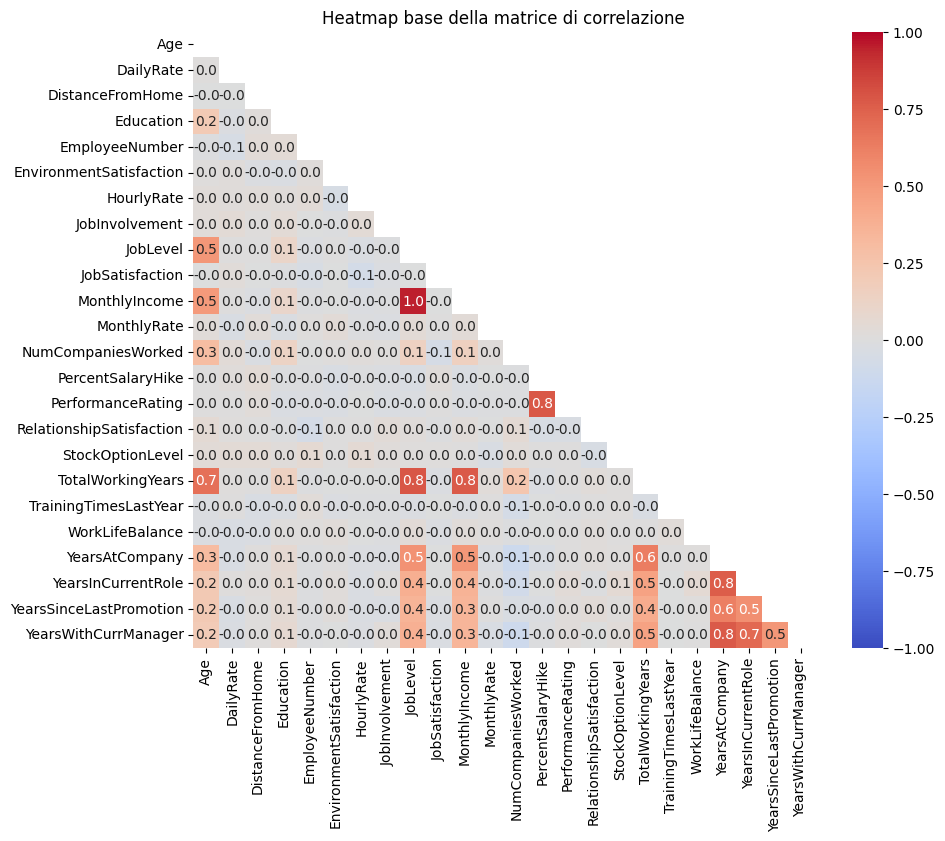

In [ ]:

attrition_senzacostanti = attrition.drop(
    columns=["EmployeeCount", "StandardHours"]
)
attrition_numerico = attrition_senzacostanti.select_dtypes(include="number")
corr_pearson = attrition_numerico.corr(method="pearson")

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr_pearson, mask=mask, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, fmt=".1f")
plt.title("Heatmap base della matrice di correlazione")
plt.show()

La correlazione più forte si riscontra tra il ruolo aziendale ricoperto e lo stipendio mensile, pari a 1,1. Correlazioni interessanti riguardano gli anni di lavoro nell'azienda. Più anni si passano in azienda più si tende a ricoprire lo stesso ruolo e rimanere sotto lo stesso manager, entrambe le correlazioni sono infatti a 0,8.

## Domanda 2
Tra uomini e donne, chi abbandona di più l'azienda?

Calcoliamo la percentuale di uomini e donne che abbandonano o non abbandonano il lavoro

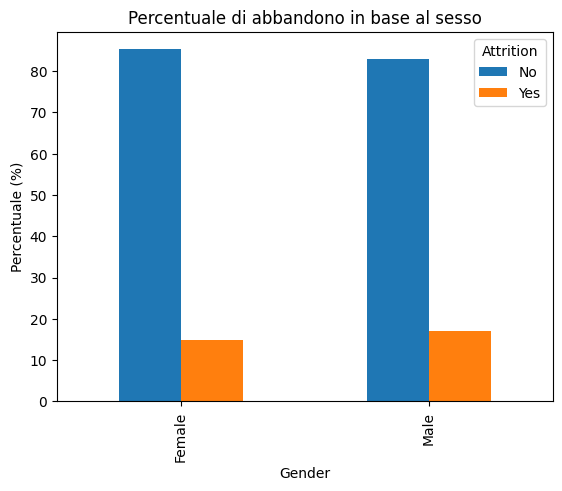

In [ ]:

attrition_gender = pd.crosstab(
    attrition['Gender'],
    attrition['Attrition'],
    normalize='index'
) * 100

# faccio un barplot
attrition_gender.plot(kind='bar')
plt.ylabel('Percentuale (%)')
plt.title('Percentuale di abbandono in base al sesso')
plt.show()

Le percentuali sono molto simili, con una leggera tendenza delle donne a non abbandonare l'azienda.

## Domanda 3
Come varia l'abbandono in base agli aumenti di stipendio?

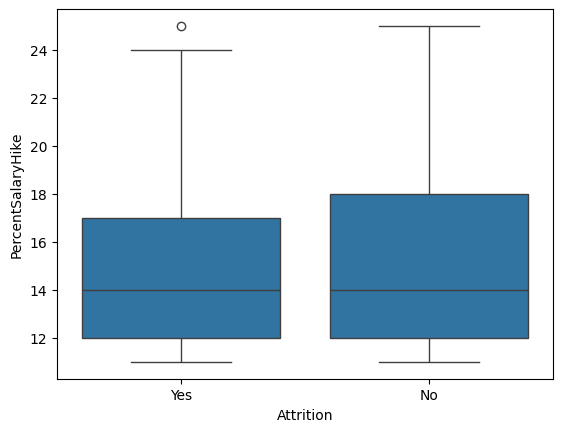

In [ ]:
sns.boxplot(x="Attrition", y="PercentSalaryHike", data=attrition)
plt.show()

Le mediane sono sostanzialmente identiche e la distribuzione è simile in entrambe le classi. Si nota un leggera differenza nei valori elevati, la quale suggerisce la tendenza a rimanere in azienda da parte di coloro che hanno ottenuto aumenti molto elevati.

## Domanda 4
Il numero degli abbandoni varia in base a quando è stata ottenuta l'ultima promozione?

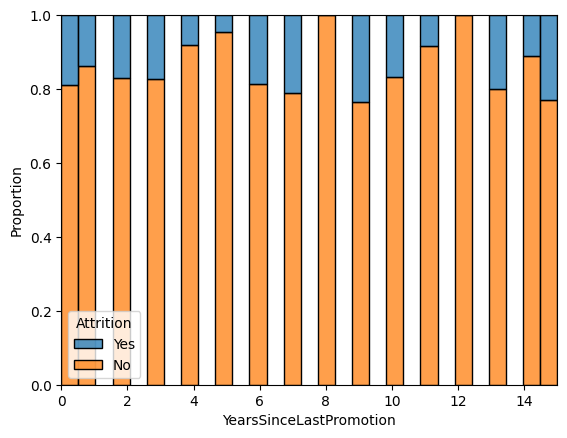

In [ ]:
sns.histplot(x="YearsSinceLastPromotion", hue="Attrition", multiple="fill", data=attrition, stat="proportion")
plt.show()

Il grafico non rileva tendenze omogenee.

##Domanda 5
Chi abbandona l’azienda che caratteristiche ha in relazione all’anzianità lavorativa e all’ammontare dello stipendio? (ad esempio, abbandona di più chi ha poca anzianità e stipendio basso?)

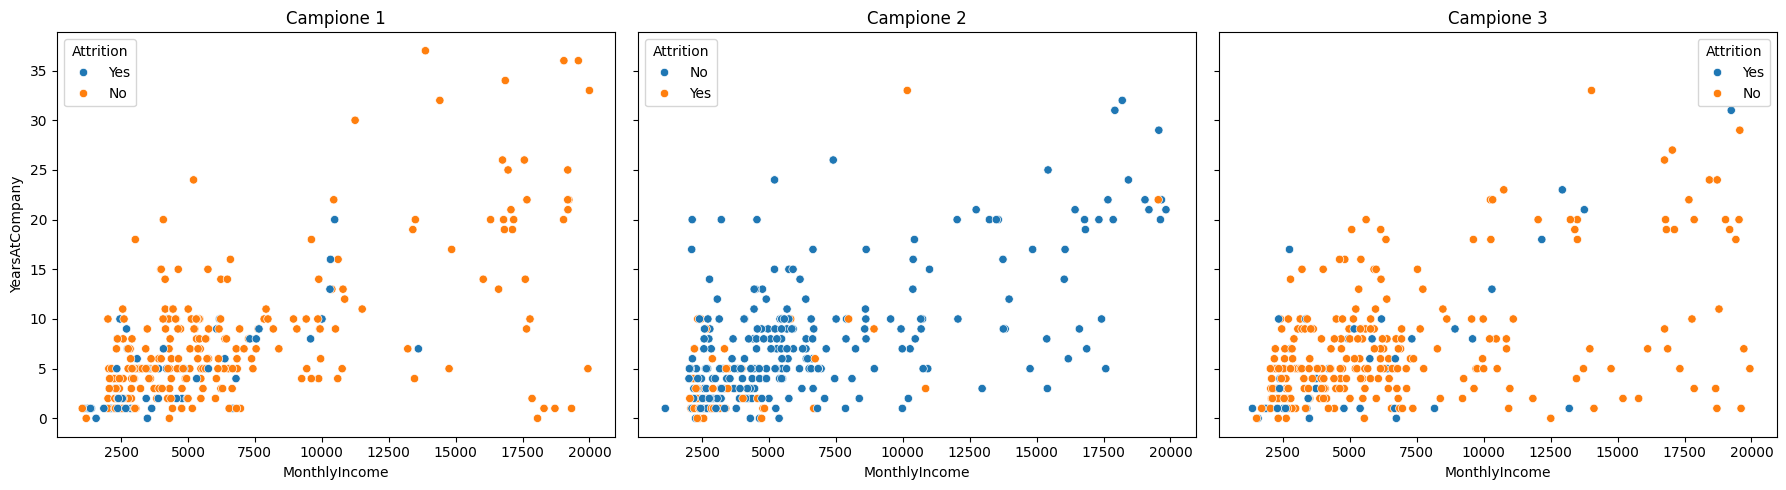

In [ ]:
sample1 = attrition.sample(300, random_state=1)
sample2 = attrition.sample(300, random_state=2)
sample3 = attrition.sample(300, random_state=3)
samples = [sample1, sample2, sample3]
titles = ["Campione 1", "Campione 2", "Campione 3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, sample, title in zip(axes, samples, titles):
    sns.scatterplot(
        data=sample,
        x="MonthlyIncome",
        y="YearsAtCompany",
        hue="Attrition",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("MonthlyIncome")
    ax.set_ylabel("YearsAtCompany")

plt.tight_layout()
plt.show()

Dal grafico emerge come una superiore anzianità e uno stipendio elevato tendono a limitare notevolmente gli abbandoni, viceversa una bassa anzianità e un minore stipendio aumentano notevolmente le probabilità di abbandono.

## Domanda 6
Chi è fermo nello stesso ruolo da diversi anni è più propenso ad abbandonare l’azienda?

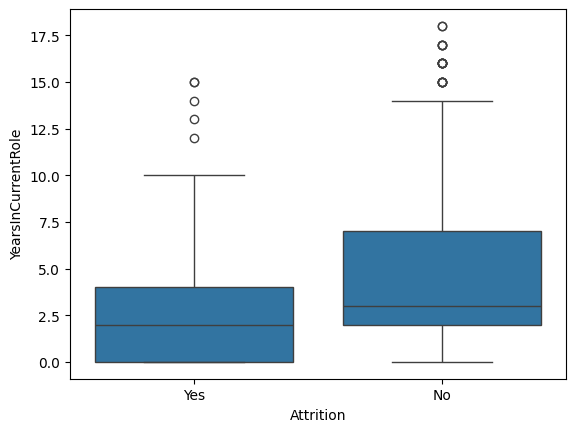

In [ ]:
sns.boxplot(data=attrition, x="Attrition", y="YearsInCurrentRole")
plt.show()

Il grafico suggerisce come numerosi anni nello stesso ruolo tendano a favorire la permanenza nell'azienda. La mediana di chi lascia l'azienda è infatti inferiore, insieme alla distribuzione.

## Domanda 7
Tra i dipendenti che hanno abbandonato e quelli che sono rimasti, come varia la distribuzione del Work-Life Balance in funzione della presenza o meno di straordinari?

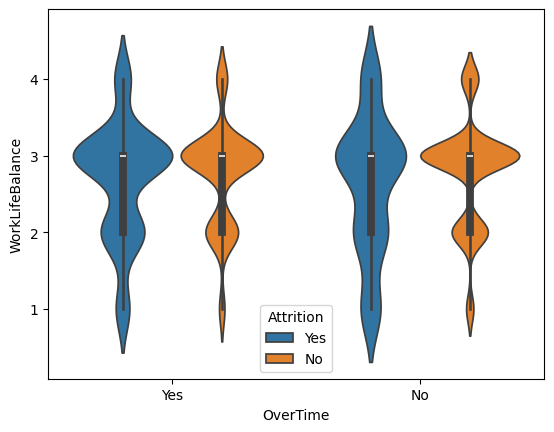

In [ ]:
sns.violinplot(data=attrition, x="OverTime", y="WorkLifeBalance", hue = "Attrition")
plt.show()

Il grafico evidenzia come nel caso in cui gli straordinari agiscono negativamente sul work-life balance, il tasso di abbandono da parte dei dipendenti sia maggiore.

#Modellazione

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

Eliminiamo alcune variabili che non forniscono informazione utile:
- EmployeeNumber (identificativo)
- EmployeeCount (costante)
- Over18 (costante)
- StandardHours (costante)

In [ ]:
attrition = attrition.drop(
    columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
)
print(attrition.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Esportiamo il dataset privo di queste colonne in file CSV.

In [ ]:
attrition.to_csv("attrition_senza_costanti.csv", index=False)

Conversione delle variabili categoriche in variabili numeriche

Tali variabili sono state convertite in dummies (possono assumere solo valori 0,1) per evitare che si convertissero in ordinali assegnando un valore per ogni categoriale.

In [ ]:
# Variabile target
attrition['Attrition'] = attrition['Attrition'].map({'No': 0, 'Yes': 1}).astype(int)

# One-hot encoding delle categoriche
attrition = pd.get_dummies(attrition, drop_first=True)

# Convertiamo i valori booleani in interi
bool_cols = attrition.select_dtypes(include='bool').columns
attrition[bool_cols] = attrition[bool_cols].astype(int)

print(attrition.dtypes)

Age                                  int64
Attrition                            int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtCompany                       int64
YearsInCurrentRole                   int64
YearsSinceLastPromotion              int64
YearsWithCu

Dividiamo i dati in:

- Training set → usato per addestrare;
- Test set → usato per valutare.

Usiamo `stratify=y` per mantenere proporzioni simili delle classi in training e test.

In [ ]:
X = attrition.drop(columns=["Attrition"])
y = attrition["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1029, 44)
Test set: (441, 44)


In [ ]:
X

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,92,2,1,3,2090,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,1,40,3,1,2,3468,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,1,0,0,0,0,0,0,1,0,0
1466,39,613,6,1,4,42,2,3,1,9991,...,0,0,0,0,0,0,0,1,0,0
1467,27,155,4,3,2,87,4,2,2,6142,...,0,0,1,0,0,0,0,1,0,1
1468,49,1023,2,3,4,63,2,2,2,5390,...,0,0,0,0,0,1,0,1,0,0


In [ ]:
y

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


In [ ]:
train_convertito = X_train.copy()
train_convertito["Attrition"] = y_train.values

test_convertito = X_test.copy()
test_convertito["Attrition"] = y_test.values

train_convertito.to_csv("train_convertito_pulito.csv", index=False)
test_convertito.to_csv("test_convertito_pulito.csv", index=False)

## **Regressione Logistica**

Prima di procedere con la regressione, standardiziamo le variabili.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Addestriamo la regressione logistica con il training set.

In [ ]:
%%time
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

CPU times: user 32.4 ms, sys: 0 ns, total: 32.4 ms
Wall time: 20.2 ms


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

- `max_iter=1000`: evita eventuali warning di mancata convergenza, soprattutto quando hai molte variabili dopo il one-hot encoding.
- `random_state=42`: rende i risultati riproducibili quando ci sono componenti che possono introdurre casualità.
- Poiché la variabile target presenta uno sbilanciamento tra le classi (i casi di attrition sono nettamente meno frequenti), è stato utilizzato il parametro `class_weight='balanced'`, che assegna un peso maggiore alla classe minoritaria durante l'addestramento, riducendo il rischio che il modello privilegi eccessivamente la classe maggioritaria.

###Facciamo delle predizioni

Predizione diretta (soglia 0.5)

In [ ]:
y_pred_log_05 = log_model.predict(X_test_scaled)

acc_log_05 = accuracy_score(y_test, y_pred_log_05)
print(f"Accuratezza della Regressione Logistica (soglia 0.5): {acc_log_05:.2f}")

Accuratezza della Regressione Logistica (soglia 0.5): 0.76


In [ ]:
print("Classification Report - Regressione Logistica (soglia 0.5)")
print(classification_report(y_test, y_pred_log_05, target_names=["No Attrition", "Attrition"]))

Classification Report - Regressione Logistica (soglia 0.5)
              precision    recall  f1-score   support

No Attrition       0.93      0.77      0.84       370
   Attrition       0.36      0.68      0.47        71

    accuracy                           0.76       441
   macro avg       0.64      0.72      0.66       441
weighted avg       0.84      0.76      0.78       441



il modello riesce a individuare il 77% dei dipendenti che rimangono in azienda, e il 93% dei casi in cui prevede la permanenza del dipendente sono corretti. viceversa il modello prevede il 68% degli abbandoni e solamente il 36% delle previsioni di abbandono si rivela corretto. l'F1-score maggiore nei casi di mancato abbandono e minore nei casi di abbandono è spiegabile dalla netta maggioranza di dati della prima classe. Per lo stesso motivo l'accuratezza genrale risulta ingannevole, poiché la classe maggioritaria supera di molto la classe degli abbandoni.

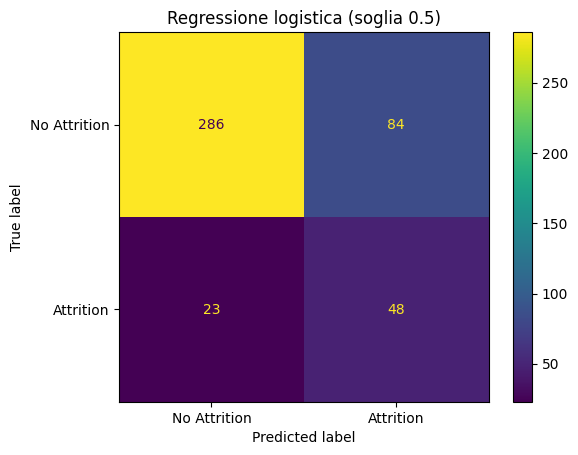

In [ ]:
cm = confusion_matrix(y_test, y_pred_log_05)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Regressione logistica (soglia 0.5)")
plt.show()

il modello ha predetto correttamente l'abbandono di 48 dipendenti e il mancato abbandono di 286 dipendenti. Ha invece predetto l'abbandono di 84 dipendenti che sono invece rimasti e il mancato abbandono di 23 dipendenti che invece hanno abbandonato l'azienda.

Applichiamo ora con una soglia diversa, scelta da noi (0.7)

In [ ]:
# probabilità predetta di Attrition = 1
predicted_prob_test = log_model.predict_proba(X_test_scaled)[:, 1]

# soglia decisionale
threshold = 0.7

# trasformo le probabilità in classi 0/1
y_pred_log_07 = (predicted_prob_test >= threshold).astype(int)

# accuracy
acc_log_07 = accuracy_score(y_test, y_pred_log_07)
print(f"Accuratezza della Regressione Logistica (soglia 0.7): {acc_log_07:.2f}")


Accuratezza della Regressione Logistica (soglia 0.7): 0.85


In [ ]:
print("Classification Report - Regressione Logistica (soglia 0.7)")
print(classification_report(y_test, y_pred_log_07, target_names=["No Attrition", "Attrition"]))

Classification Report - Regressione Logistica (soglia 0.7)
              precision    recall  f1-score   support

No Attrition       0.91      0.91      0.91       370
   Attrition       0.54      0.54      0.54        71

    accuracy                           0.85       441
   macro avg       0.73      0.72      0.73       441
weighted avg       0.85      0.85      0.85       441



Applicando la nuova soglia la precision nella classe "Attrition" aumenta, arrivando al 54% di previsioni di abbandono corrette. Viceversa la recall si riduce, pertanto il modello riesce a prevedere solo il 54% di abbandoni rispetto al 68% di prima. L'accuratezza complessiva aumenta fino all'85%, ciò è comunque dovuto alla composizione del campione, in gran maggioranza formato da soggetti che non abbandonano l'azienda.

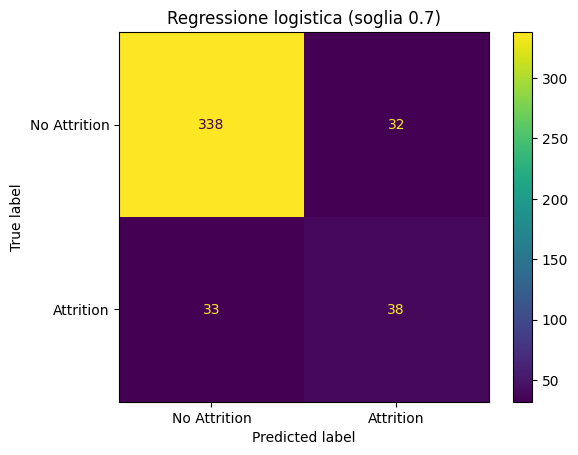

In [ ]:
cm = confusion_matrix(y_test, y_pred_log_07)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Regressione logistica (soglia 0.7)")
plt.show()

Con la nuova soglia il modello prevede correttamente 338 dipendenti che rimangono in azienda e 38 dipendenti che abbandonano. Commette errori prevedendo 32 abbandoni di dipendenti invece rimasti in azienda e prevedendo 33 dipendenti rimasti che hanno invece abbandonato l'azienda.

Oltre alle metriche di valutazione, vogliamo capire cosa il modello ha effettivamente imparato dai dati.  
La regressione logistica assegna a ciascuna variabile un coefficiente, che indica sia la direzione (positiva o negativa) sia l'intensità del suo effetto sulla probabilità stimata di abbandono. Analizzare questi coefficienti ci permette di confrontare l'interpretazione del modello con le ipotesi formulate nell'analisi esplorativa, e di capire quali caratteristiche dei dipendenti il modello considera più rilevanti per prevedere l'Attrition.

In [ ]:
# Coefficienti della regressione logistica
coefficienti = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficiente": log_model.coef_[0]
})

coefficienti = coefficienti.sort_values(by="Coefficiente", ascending=False)
coefficienti

,Feature,Coefficiente
34,JobRole_Laboratory Technician,0.798219
39,JobRole_Sales Executive,0.791995
43,OverTime_Yes,0.784311
7,JobLevel,0.775677
40,JobRole_Sales Representative,0.713505
23,BusinessTravel_Travel_Frequently,0.680359
21,YearsSinceLastPromotion,0.597166
42,MaritalStatus_Single,0.517301
11,NumCompaniesWorked,0.503046
25,Department_Research & Development,0.455943


Dall'analisi della tabella emerge una forte coerenza per Age (-0.279) e MonthlyIncome (-0.404), i cui coefficienti significativi confermano quanto visto nell'analisi esplorativa (età e reddito bassi aumentano il rischio di abbandono). Al contrario, YearsAtCompany presenta un coefficiente quasi nullo (+0.103) e di segno opposto rispetto al trend empirico isolato, dove una maggiore anzianità riduceva il turnover. Questo fenomeno è un effetto della multicollinearità già evidenziata nella heatmap: l'informazione sull'anzianità è infatti divisa su quattro variabili fortemente correlate (YearsInCurrentRole, YearsWithCurrManager e soprattutto TotalWorkingYears, che registra il coefficiente più negativo di -0.576). Nel modello multivariato queste variabili si "diluiscono" a vicenda e il peso statistico principale viene assorbito da TotalWorkingYears, lasciando a YearsAtCompany solo un contributo residuo.

### Come variano le probabilità di Attrition stimate dal modello al variare di una specifica variabile (Age, MonthlyIncome e YearsAtCompany)?

Come si distribuiscono le probabilità predette di attrition rispetto all'età?

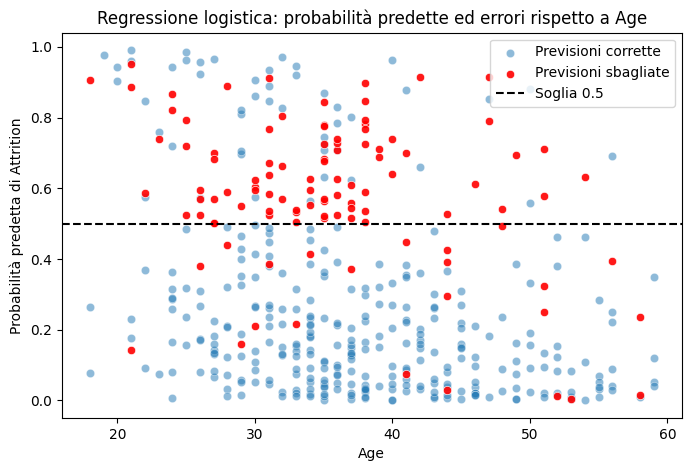

In [ ]:
# variabile da visualizzare
feature = "Age"

# probabilità predette sul test set
predicted_prob_test = log_model.predict_proba(X_test_scaled)[:, 1]

# soglia decisionale
threshold = 0.5

# dataframe per il grafico
df_plot = X_test.copy()

df_plot["Attrition"] = y_test.values
df_plot["predicted_prob"] = predicted_prob_test
df_plot["predicted_class"] = (
    df_plot["predicted_prob"] >= threshold
).astype(int)

# individua gli errori
df_plot["wrong_prediction"] = (
    df_plot["predicted_class"] != df_plot["Attrition"]
)

plt.figure(figsize=(8, 5))

# previsioni corrette
sns.scatterplot(
    data=df_plot[df_plot["wrong_prediction"] == False],
    x=feature,
    y="predicted_prob",
    alpha=0.5,
    label="Previsioni corrette"
)

# previsioni sbagliate
sns.scatterplot(
    data=df_plot[df_plot["wrong_prediction"] == True],
    x=feature,
    y="predicted_prob",
    color="red",
    alpha=0.9,
    label="Previsioni sbagliate"
)

# linea della soglia
plt.axhline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Soglia {threshold}"
)

plt.title(
    f"Regressione logistica: probabilità predette ed errori rispetto a {feature}"
)

plt.xlabel(feature)
plt.ylabel("Probabilità predetta di Attrition")
plt.legend()
plt.show()

Il grafico conferma il coefficiente negativo associato all'età. Aumentando l'età le probabilità predette di abbandono si riducono. I punti rossi sotto soglia rappresentano i falsi negativi, mentre la concetrazione di punti rossi tra 25 e 40 sopra soglia rappresenta un importante numero di falsi positivi (dipendenti che non hanno abbandonato l'azienda ai quali è stata però assegnata un'alta probabilità di abbandono).

Come si distribuiscono le probabilità predette di attrition rispetto al reddito mensile?

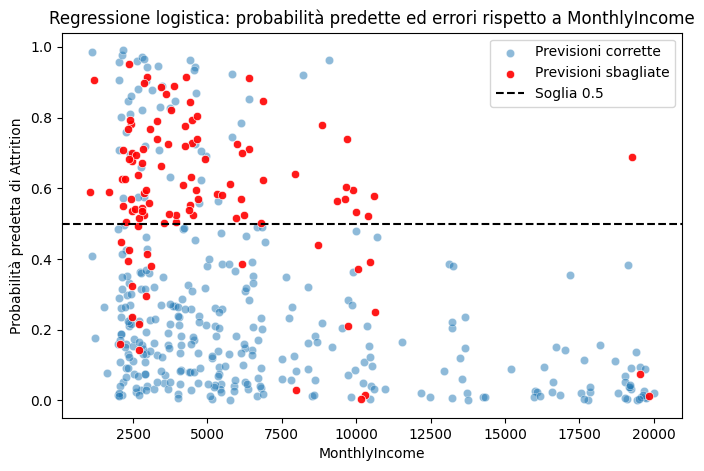

In [ ]:
# variabile da visualizzare
feature = "MonthlyIncome"

# probabilità predette sul test set
predicted_prob_test = log_model.predict_proba(X_test_scaled)[:, 1]

# soglia decisionale
threshold = 0.5

# dataframe per il grafico
df_plot = X_test.copy()

df_plot["Attrition"] = y_test.values
df_plot["predicted_prob"] = predicted_prob_test
df_plot["predicted_class"] = (
    df_plot["predicted_prob"] >= threshold
).astype(int)

# individua gli errori
df_plot["wrong_prediction"] = (
    df_plot["predicted_class"] != df_plot["Attrition"]
)

plt.figure(figsize=(8, 5))

# previsioni corrette
sns.scatterplot(
    data=df_plot[df_plot["wrong_prediction"] == False],
    x=feature,
    y="predicted_prob",
    alpha=0.5,
    label="Previsioni corrette"
)

# previsioni sbagliate
sns.scatterplot(
    data=df_plot[df_plot["wrong_prediction"] == True],
    x=feature,
    y="predicted_prob",
    color="red",
    alpha=0.9,
    label="Previsioni sbagliate"
)

# linea della soglia
plt.axhline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Soglia {threshold}"
)

plt.title(
    f"Regressione logistica: probabilità predette ed errori rispetto a {feature}"
)

plt.xlabel(feature)
plt.ylabel("Probabilità predetta di Attrition")
plt.legend()
plt.show()

Anche in questo caso il grafico riflette il coefficiente negativo associato alla variabile. All'aumentare del reddito mensile le probabilità di abbandono stimate crollano. La maggioranza di falsi positivi si concentra nelle fasce di reddito più basse, sotto i 5000 dollari, mentre nelle fasce alte, sopra i 20.000, emerge un unico falso negativo (outlier). Il modello mostra pertanto numerosi errori nei redditi bassi e una buona capacità di previsione nei redditi alti.

Come si distribuiscono le probabilità predette di attrition rispetto all'anzianità aziendale?

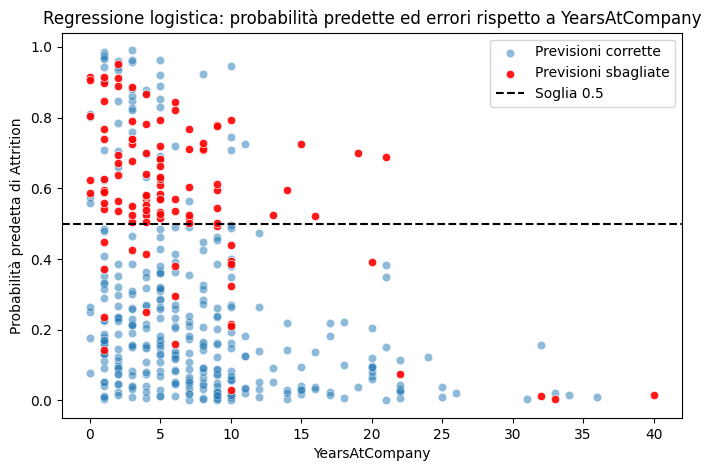

In [ ]:
# variabile da visualizzare
feature = "YearsAtCompany"

# probabilità predette sul test set
predicted_prob_test = log_model.predict_proba(X_test_scaled)[:, 1]

# soglia decisionale
threshold = 0.5

# dataframe per il grafico
df_plot = X_test.copy()

df_plot["Attrition"] = y_test.values
df_plot["predicted_prob"] = predicted_prob_test
df_plot["predicted_class"] = (
    df_plot["predicted_prob"] >= threshold
).astype(int)

# individua gli errori
df_plot["wrong_prediction"] = (
    df_plot["predicted_class"] != df_plot["Attrition"]
)

plt.figure(figsize=(8, 5))

# previsioni corrette
sns.scatterplot(
    data=df_plot[df_plot["wrong_prediction"] == False],
    x=feature,
    y="predicted_prob",
    alpha=0.5,
    label="Previsioni corrette"
)

# previsioni sbagliate
sns.scatterplot(
    data=df_plot[df_plot["wrong_prediction"] == True],
    x=feature,
    y="predicted_prob",
    color="red",
    alpha=0.9,
    label="Previsioni sbagliate"
)

# linea della soglia
plt.axhline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Soglia {threshold}"
)

plt.title(
    f"Regressione logistica: probabilità predette ed errori rispetto a {feature}"
)

plt.xlabel(feature)
plt.ylabel("Probabilità predetta di Attrition")
plt.legend()
plt.show()

## **k-Nearest Neighbors (k-NN)**

In [ ]:
# Addestriamo un k-NN con k=5
%%time
knn_model_k5 = KNeighborsClassifier(n_neighbors=5)
knn_model_k5.fit(X_train_scaled, y_train)

CPU times: user 1.71 ms, sys: 942 µs, total: 2.65 ms
Wall time: 2.83 ms


KNeighborsClassifier()

###Facciamo delle predizioni

In [ ]:
y_pred_knn_k5 = knn_model_k5.predict(X_test_scaled)

acc_knn_k5 = accuracy_score(y_test, y_pred_knn_k5)
print(f"Accuratezza del k-NN (k=5): {acc_knn_k5:.2f}")

Accuratezza del k-NN (k=5): 0.84


In [ ]:
print("Classification Report - k-NN (k=5)")
print(classification_report(y_test, y_pred_knn_k5, target_names=["No Attrition", "Attrition"]))

Classification Report - k-NN (k=5)
              precision    recall  f1-score   support

No Attrition       0.85      0.99      0.91       370
   Attrition       0.50      0.07      0.12        71

    accuracy                           0.84       441
   macro avg       0.67      0.53      0.52       441
weighted avg       0.79      0.84      0.78       441



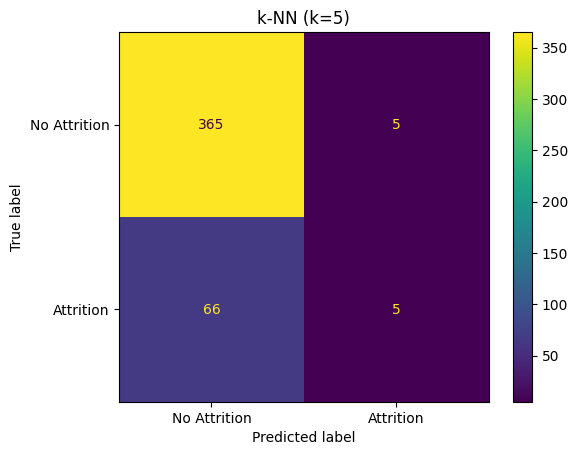

In [ ]:
cm_knn_k5 = confusion_matrix(y_test, y_pred_knn_k5)
disp_knn_k5 = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_k5,
    display_labels=["No Attrition", "Attrition"]
)
disp_knn_k5.plot()
plt.title("k-NN (k=5)")
plt.show()

Proviamo ora con un k diverso, scelto da noi (3)

In [ ]:
# Addestriamo un k-NN con k=3
%%time
knn_model_k3 = KNeighborsClassifier(n_neighbors=3)
knn_model_k3.fit(X_train_scaled, y_train)

CPU times: user 2.64 ms, sys: 0 ns, total: 2.64 ms
Wall time: 4.32 ms


KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred_knn_k3 = knn_model_k3.predict(X_test_scaled)

acc_knn_k3 = accuracy_score(y_test, y_pred_knn_k3)
print(f"Accuratezza del k-NN (k=3): {acc_knn_k3:.2f}")

Accuratezza del k-NN (k=3): 0.83


In [ ]:
print("Classification Report - k-NN (k=3)")
print(classification_report(y_test, y_pred_knn_k3, target_names=["No Attrition", "Attrition"]))

Classification Report - k-NN (k=3)
              precision    recall  f1-score   support

No Attrition       0.85      0.97      0.91       370
   Attrition       0.43      0.13      0.20        71

    accuracy                           0.83       441
   macro avg       0.64      0.55      0.55       441
weighted avg       0.78      0.83      0.79       441



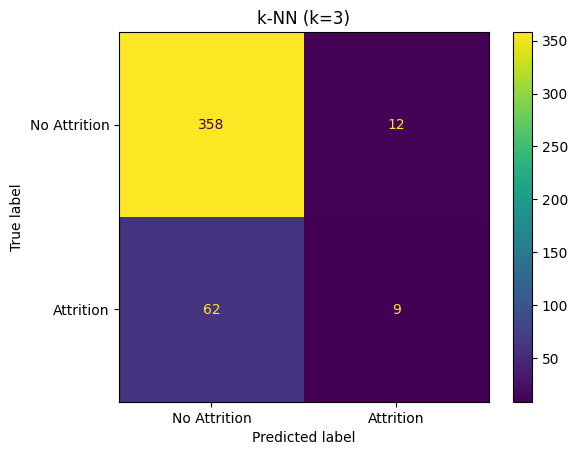

In [ ]:
cm_knn_k3 = confusion_matrix(y_test, y_pred_knn_k3)
disp_knn_k3 = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_k3,
    display_labels=["No Attrition", "Attrition"]
)
disp_knn_k3.plot()
plt.title("k-NN (k=3)")
plt.show()

## **Random Forest**

In [ ]:
%%time
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

CPU times: user 304 ms, sys: 0 ns, total: 304 ms
Wall time: 305 ms


RandomForestClassifier(class_weight='balanced', random_state=42)

- `n_estimators=100`: numero di alberi nella foresta (valore di default, un buon compromesso tra qualità delle previsioni e tempo di calcolo).
- `class_weight='balanced'`: stesso motivo della regressione logistica — compensa lo sbilanciamento tra le classi assegnando più peso ai casi minoritari di Attrition durante l'addestramento.
- `random_state=42`: rende l'addestramento riproducibile (la costruzione degli alberi ha componenti casuali, es. quali feature considerare a ogni split).

###Facciamo delle predizioni

In [ ]:
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuratezza del Random Forest: {acc_rf:.2f}")

Accuratezza del Random Forest: 0.83


In [ ]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["No Attrition", "Attrition"]))

Classification Report - Random Forest
              precision    recall  f1-score   support

No Attrition       0.85      0.98      0.91       370
   Attrition       0.43      0.08      0.14        71

    accuracy                           0.83       441
   macro avg       0.64      0.53      0.52       441
weighted avg       0.78      0.83      0.78       441



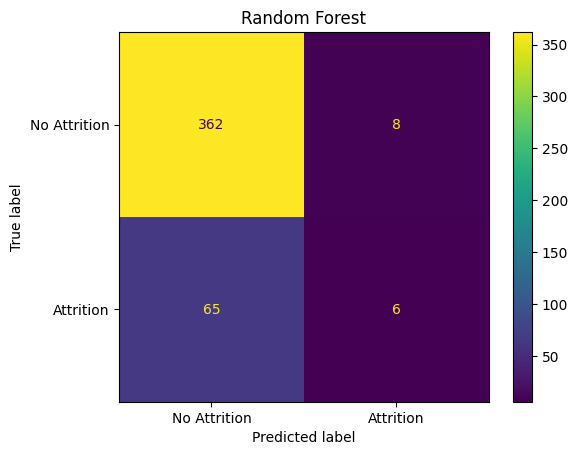

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Attrition", "Attrition"]
)
disp_rf.plot()
plt.title("Random Forest")
plt.show()

Il Random Forest permette di calcolare la feature importance: una misura di quanto ciascuna variabile sia stata utile al modello per separare le due classi durante la costruzione degli alberi decisionali.  
Un valore più alto indica che quella variabile ha contribuito maggiormente alle decisioni del modello.

In [ ]:
# Feature importance del Random Forest
importanze = pd.DataFrame({
    "Feature": X_train.columns,
    "Importanza": rf_model.feature_importances_
})

importanze = importanze.sort_values(by="Importanza", ascending=False)
importanze

,Feature,Importanza
9,MonthlyIncome,0.076746
0,Age,0.064730
19,YearsAtCompany,0.051133
16,TotalWorkingYears,0.050205
22,YearsWithCurrManager,0.046302
1,DailyRate,0.046174
10,MonthlyRate,0.045320
5,HourlyRate,0.044057
2,DistanceFromHome,0.042458
15,StockOptionLevel,0.040597


### Come variano le performance e il tempo di addestramento del Random Forest al variare del numero di alberi?

In [ ]:
import time
from sklearn.metrics import recall_score

valori_n_estimators = [10, 50, 100, 200, 500, 1000]
risultati = []

for n in valori_n_estimators:
    inizio = time.time()

    modello_temp = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',
        random_state=42
    )
    modello_temp.fit(X_train, y_train)

    tempo_addestramento = time.time() - inizio

    y_pred_temp = modello_temp.predict(X_test)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    recall_temp = recall_score(y_test, y_pred_temp, pos_label=1)

    risultati.append({
        "n_estimators": n,
        "accuracy": acc_temp,
        "recall_attrition": recall_temp,
        "tempo_addestramento": tempo_addestramento
    })

risultati_df = pd.DataFrame(risultati)
risultati_df

,n_estimators,accuracy,recall_attrition,tempo_addestramento
0,10,0.829932,0.084507,0.042125
1,50,0.829932,0.070423,0.174519
2,100,0.834467,0.084507,0.339002
3,200,0.839002,0.084507,0.827598
4,500,0.841270,0.098592,2.374113
5,1000,0.841270,0.098592,3.139384


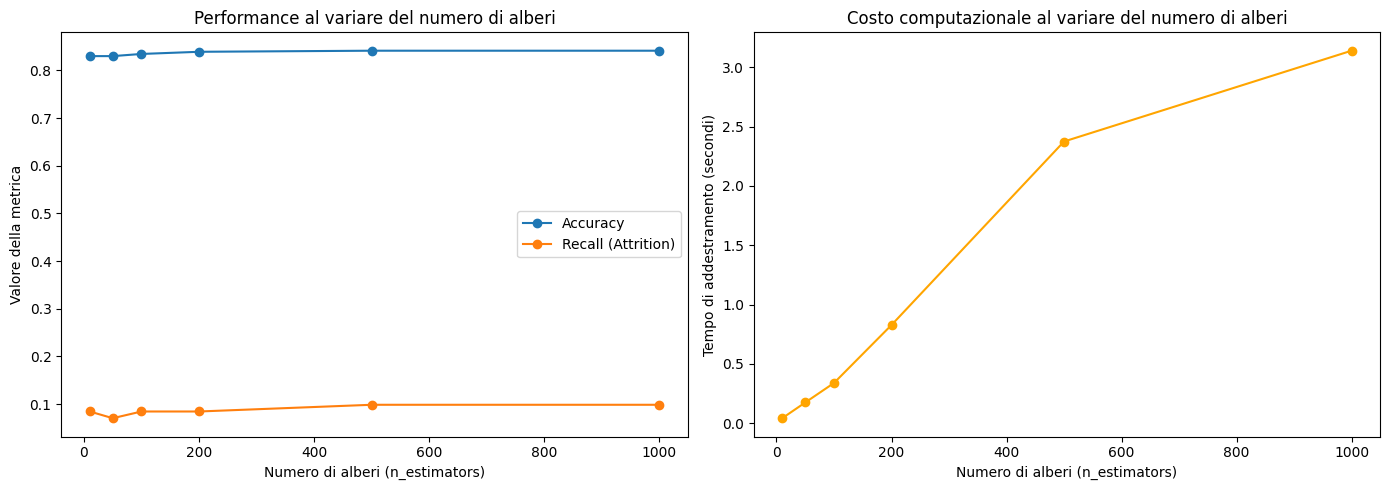

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(risultati_df["n_estimators"], risultati_df["accuracy"], marker="o", label="Accuracy")
axes[0].plot(risultati_df["n_estimators"], risultati_df["recall_attrition"], marker="o", label="Recall (Attrition)")
axes[0].set_xlabel("Numero di alberi (n_estimators)")
axes[0].set_ylabel("Valore della metrica")
axes[0].set_title("Performance al variare del numero di alberi")
axes[0].legend()

axes[1].plot(risultati_df["n_estimators"], risultati_df["tempo_addestramento"], marker="o", color="orange")
axes[1].set_xlabel("Numero di alberi (n_estimators)")
axes[1].set_ylabel("Tempo di addestramento (secondi)")
axes[1].set_title("Costo computazionale al variare del numero di alberi")

plt.tight_layout()
plt.show()

#Confronto tra Modelli


Per confrontare i tre modelli, riportiamo in un'unica tabella le metriche calcolate sul Test set per le versioni "ufficiali" di ciascun modello:
- la Regressione Logistica a soglia 0.5
- il k-NN con k=5
- il Random Forest con 100 alberi.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def metriche_modello(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average="binary"
    )
    return accuracy, precision, recall, f1

acc_log, prec_log, rec_log, f1_log = metriche_modello(y_test, y_pred_log_05)
acc_knn, prec_knn, rec_knn, f1_knn = metriche_modello(y_test, y_pred_knn_k5)
acc_rf, prec_rf, rec_rf, f1_rf = metriche_modello(y_test, y_pred_rf)

confronto_modelli = pd.DataFrame({
    "Modello": ["Regressione Logistica (soglia 0.5)", "k-NN (k=5)", "Random Forest (100 alberi)"],
    "Accuracy": [acc_log, acc_knn, acc_rf],
    "Precision (Attrition)": [prec_log, prec_knn, prec_rf],
    "Recall (Attrition)": [rec_log, rec_knn, rec_rf],
    "F1-score (Attrition)": [f1_log, f1_knn, f1_rf]
})

confronto_modelli = confronto_modelli.round(2)
confronto_modelli

,Modello,Accuracy,Precision (Attrition),Recall (Attrition),F1-score (Attrition)
0,Regressione Logistica (soglia 0.5),0.76,0.36,0.68,0.47
1,k-NN (k=5),0.84,0.50,0.07,0.12
2,Random Forest (100 alberi),0.83,0.43,0.08,0.14


## Cross-validation (10-fold)

Le metriche calcolate finora si basano su un singolo Train/Test split, il cui risultato può dipendere in parte da quali osservazioni sono finite per caso nel Test set.  
Per ottenere una stima più robusta e confrontare i tre modelli in modo più rigoroso, applichiamo una 10-fold cross validation a ciascuno di essi, usando le configurazioni "ufficiali" già scelte nelle sezioni precedenti (Regressione Logistica a soglia 0.5, k-NN con k=5, Random Forest con 100 alberi).

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline

# 10 fold stratificati (mantengono le proporzioni delle classi in ogni fold) con shuffle per evitare di dipendere dall'ordine originale dei dati
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Per Regressione Logistica e k-NN usiamo una pipeline che include la standardizzazione, così viene ricalcolata separatamente su ogni fold (evitando data leakage tra training e validation all'interno della CV)
pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("modello", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modello", KNeighborsClassifier(n_neighbors=5))
])

# Il Random Forest non necessita di standardizzazione
modello_rf_cv = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [ ]:
metriche_cv = ["accuracy", "precision", "recall", "f1"]

cv_log = cross_validate(pipeline_log, X_train, y_train, cv=cv_strategy, scoring=metriche_cv)
cv_knn = cross_validate(pipeline_knn, X_train, y_train, cv=cv_strategy, scoring=metriche_cv)
cv_rf = cross_validate(modello_rf_cv, X_train, y_train, cv=cv_strategy, scoring=metriche_cv)

In [ ]:
def cv_summary(cv_result, metrica):
    media = cv_result[f"test_{metrica}"].mean()
    std = cv_result[f"test_{metrica}"].std()
    return f"{media:.2f} (± {std:.2f})"

risultati_cv = pd.DataFrame({
    "Modello": ["Regressione Logistica (soglia 0.5)", "k-NN (k=5)", "Random Forest"],
    "Accuracy": [cv_summary(cv_log, "accuracy"), cv_summary(cv_knn, "accuracy"), cv_summary(cv_rf, "accuracy")],
    "Precision (Attrition)": [cv_summary(cv_log, "precision"), cv_summary(cv_knn, "precision"), cv_summary(cv_rf, "precision")],
    "Recall (Attrition)": [cv_summary(cv_log, "recall"), cv_summary(cv_knn, "recall"), cv_summary(cv_rf, "recall")],
    "F1-score (Attrition)": [cv_summary(cv_log, "f1"), cv_summary(cv_knn, "f1"), cv_summary(cv_rf, "f1")],
})

risultati_cv

,Modello,Accuracy,Precision (Attrition),Recall (Attrition),F1-score (Attrition)
0,Regressione Logistica (soglia 0.5),0.76 (± 0.03),0.38 (± 0.04),0.75 (± 0.10),0.51 (± 0.06)
1,k-NN (k=5),0.85 (± 0.02),0.61 (± 0.30),0.15 (± 0.08),0.23 (± 0.12)
2,Random Forest,0.86 (± 0.02),0.83 (± 0.23),0.16 (± 0.05),0.26 (± 0.08)
